# 02. Workspace: filesystem и инструкции

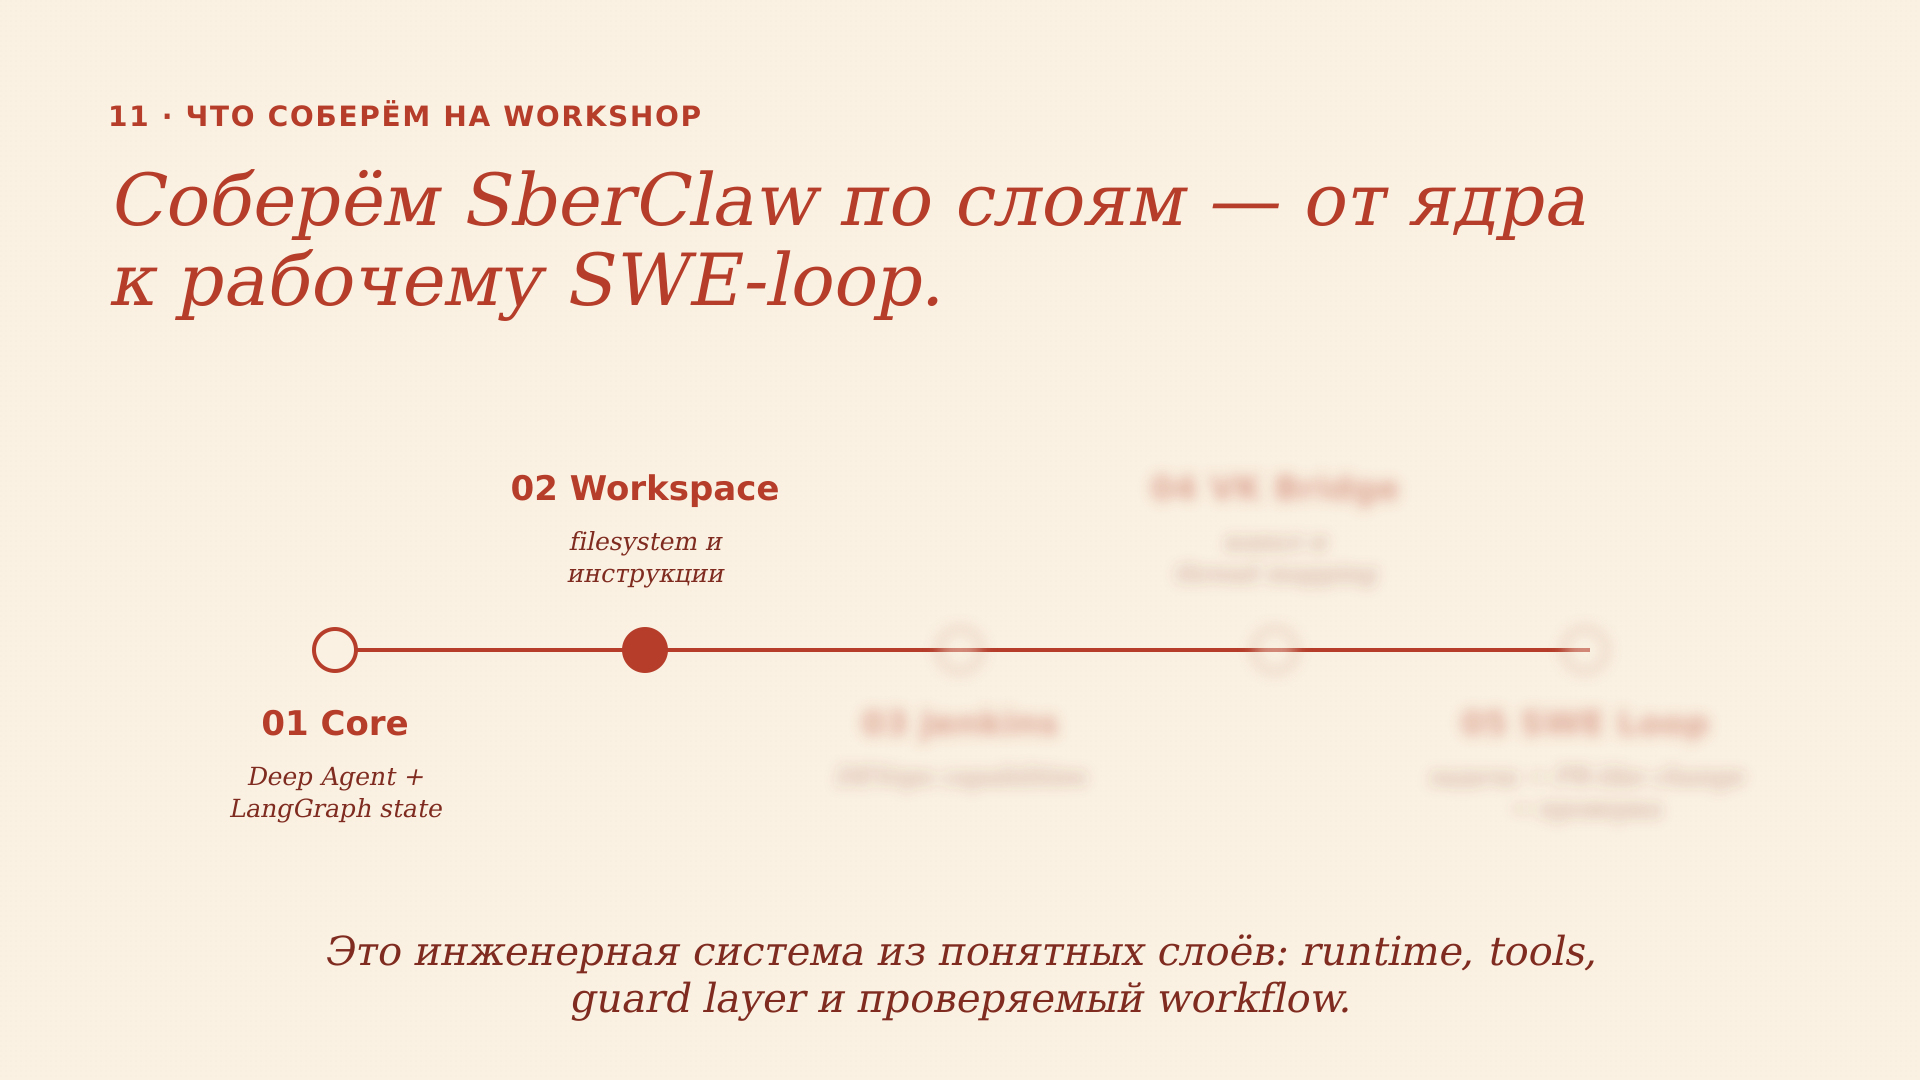

## Что такое `_backend`

`_backend` — это не tool для пользователя. Это runtime boundary для Deep Agents.

```text
Deep Agent harness
→ FilesystemMiddleware
→ _backend
→ local workspace
```

В этом workshop настройки окружения убраны из `.env`: там остаются только keys и credentials. Поэтому workspace stage жёстко показывает один режим:

```text
02 Workspace → FilesystemBackend(root_dir=REPO_ROOT, virtual_mode=True)
```

Shell появляется позже, в `05 SWE Loop`, где он нужен для pytest. Здесь агент может читать workspace, но не должен получать secrets через shell или `env`.


In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd() / 'workshop_notebooks' / 'openclaw_path'):
    if (candidate / 'workshop_utils.py').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from workshop_utils import REPO_ROOT, model_name, print_stage_context, register_graphs, workspace_root, write_text

print_stage_context()
print("pyproject:", REPO_ROOT / "pyproject.toml")

from agents.openclaw_02_workspace import _backend

backend = _backend()
print("Workspace:", workspace_root())
print("Backend class:", type(backend).__name__)
print("Backend capabilities:", [name for name in ["ls", "read", "grep", "glob", "write", "execute"] if hasattr(backend, name)])


## Инструкции важны так же, как backend

Backend даёт способность, но model всё равно должна понять, как ей пользоваться.

Поэтому system prompt явно говорит:

```text
Use ls, glob, grep, and read_file before making repository claims.
Cite inspected files.
Do not say that workspace is disabled in this graph.
```


In [ ]:
ENTRYPOINT = '''\
from __future__ import annotations

from pathlib import Path

from deepagents import create_deep_agent
from dotenv import load_dotenv

from agents.model_config import workshop_model

REPO_ROOT = Path(__file__).resolve().parents[1]

load_dotenv(REPO_ROOT / ".env")


def _workspace_root() -> Path:
    return REPO_ROOT


def _backend():
    from deepagents.backends import FilesystemBackend

    return FilesystemBackend(root_dir=_workspace_root(), virtual_mode=True)


WORKSPACE_PROMPT = """\
You are OpenClaw at stage 02 Workspace.
Respond in the user's language; default to Russian.

This graph adds a real workspace backend to the Core graph.
Use filesystem tools such as ls, glob, grep, and read_file before making
claims about repository files.

Important boundary:
- _backend connects the Deep Agent harness to the local workspace;
- filesystem paths are virtualized inside the configured workspace;
- this stage uses FilesystemBackend, not shell;
- secrets remain unavailable to filesystem tools.
"""


agent = create_deep_agent(
    model=workshop_model(),
    tools=[],
    system_prompt=WORKSPACE_PROMPT,
    backend=_backend(),
)
'''

entrypoint = write_text('agents/openclaw_02_workspace.py', ENTRYPOINT)
config_path = register_graphs({
    'openclaw_02_workspace': './agents/openclaw_02_workspace.py:agent'
})

print("Entrypoint:", entrypoint.relative_to(REPO_ROOT))
print("LangGraph config:", config_path.relative_to(REPO_ROOT))


## Проверка в LangGraph Studio

### Запрос

```text
Найди файл pyproject.toml и назови имя проекта и три зависимости. Не угадывай: сначала используй filesystem tools.
```

### Ожидаемое поведение

1. `openclaw_02_workspace` вызывает `ls`, `glob` или `read_file`.
2. Агент читает `pyproject.toml` из workspace.
3. Ответ ссылается на файл, а не на догадку.

### Что изменилось относительно предыдущего этапа

```text
01: messages + state + model
02: messages + state + model + _backend → workspace
```

### Текущее ограничение

Агент видит локальную среду, но пока не умеет выполнять DevOps actions во внешней системе.
